In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

# from FEATURES.features import *
from BACKTEST.backtestCalculateEVS import *
from BACKTEST.backtest import backtestPairs, calculatePairMetrics
# from MODELS.teamInfo import *


In [2]:
import joblib


# Load NGBoost mean and variance models
mean_model = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_MEAN_MODEL.pkl')
variance_model = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_VAR_MODEL.pkl')
calibration_factor = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_CALIBRATION_FACTOR.pkl')

models = {
    'mean': mean_model,
    'variance': variance_model,
    'calibration_factor': calibration_factor
}

features = joblib.load('../MODELS/SAVED_MODELS/feature_list.pkl')

print(f"Loaded NGBoost models with calibration factor: {calibration_factor}")
print(f"Number of features: {len(features)}")

Loaded NGBoost models with calibration factor: 1.25
Number of features: 126


In [3]:
pd.set_option('display.max_columns', None)

s25_pts = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s25_pts['IS_HIGH_SCORER'] = (s25_pts.groupby('PLAYER_ID')['PTS_AVG_TO_DATE'].transform('mean') > 18).astype(int)
s24_pts = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s24_pts['IS_HIGH_SCORER'] = (s24_pts.groupby('PLAYER_ID')['PTS_AVG_TO_DATE'].transform('mean') > 18).astype(int)

df = pd.concat([s25_pts, s24_pts]).sort_values(by='GAME_DATE')
df.sample()

,Unnamed: 0,Unnamed: 0.2,PLAYER_NAME,PLAYER_ID,MATCHUP,TEAM_ABBREVIATION,TEAM_ID,OPP_ABBREVIATION,HOME_GAME,GAME_ID,GAME_DATE,WL,PTS,AST,REB,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,STL,BLK,TOV,PLUS_MINUS,FANTASY_PTS,POINT_PER_SHOT,EFG,START_POSITION,COMMENT,E_OFF_RATING,E_DEF_RATING,NET_RATING,OREB_PCT,DREB_PCT,REB_PCT,AST_PCT,EFG_PCT,AST_TOV,USG_PCT,TS_PCT,E_PACE,PACE,PIE,POSS,PACE_PER40,E_USG_PCT,MIN,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,PTS_OFF_TOV,PTS_2ND_CHANCE,PTS_FB,PTS_PAINT,OPP_PTS_OFF_TOV,OPP_PTS_2ND_CHANCE,OPP_PTS_FB,OPP_PTS_PAINT,BLKA,PF,PFD,IS_PLAYOFF,TEAM_SEASON_ID_x,whos_favored,spread,total,team_is_favored,team_spread,OPP_BLOWOUT_RISK,TEAM_NAME,TEAM_MIN,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_STL,TEAM_BLK,TEAM_TOV,TEAM_PF,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_PACE,GAME_PACE,OPP_PACE,OPP_TEAM_ID,TEAM_OFF_RATING,TEAM_DEF_RATING,OPP_DEF_RATING,OPP_OFF_RATING,OPP_PTS,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_REB,OPP_AST,OPP_STL,OPP_BLK,OPP_TOV,percentageFieldGoalsAttempted2pt,percentageFieldGoalsAttempted3pt,percentagePoints2pt,percentagePointsMidrange2pt,percentagePoints3pt,percentagePointsFastBreak,percentagePointsFreeThrow,percentagePointsOffTurnovers,percentagePointsPaint,percentageAssisted2pt,percentageUnassisted2pt,percentageAssisted3pt,percentageUnassisted3pt,percentageAssistedFGM,percentageUnassistedFGM,matchupFieldGoalsMade,matchupFieldGoalsAttempted,matchupThreePointersMade,matchupThreePointersAttempted,playerPoints,matchupMinutes,DEF_FG_PCT_ALLOWED,DEF_3PT_PCT_ALLOWED,PTS_ALLOWED_PER_MIN,AGE,FREQ_FG3,FG3M_main,FG3A_main,FG3_PCT_main,NS_FG3_PCT,PLUS_MINUS_FG3,FREQ_FG2,FG2M,FG2A,FG2_PCT,NS_FG2_PCT,PLUS_MINUS_FG2,FREQ_LT_06,FGM_LT_06,FGA_LT_06,LT_06_PCT,NS_LT_06_PCT,PLUS_MINUS_LT_06,FREQ_LT_10,FGM_LT_10,FGA_LT_10,LT_10_PCT,NS_LT_10_PCT,PLUS_MINUS_LT_10,FREQ_GT_15,FGM_GT_15,FGA_GT_15,GT_15_PCT,NS_GT_15_PCT,PLUS_MINUS_GT_15,DEF_TOV_FORCED_PER_MIN,DEF_BLOCKS_PER_MIN,DEF_SHOOTING_FOULS_PER_MIN,DEF_AST_ALLOWED_PER_MIN,STARTING,GAMES_THIS_SEASON,HEIGHT,WEIGHT,GUARD,FORWARD,CENTER,TEAM_DAYS_REST,PLAYER_DAYS_REST,TEAM_B2B,IS_BACK_TO_BACK,PLAYER_MISSED_LAST,PTS_ROLLING_AVG_5,AST_ROLLING_AVG_5,FGM_ROLLING_AVG_5,FGA_ROLLING_AVG_5,FG_PCT_ROLLING_AVG_5,FG3M_ROLLING_AVG_5,FG3A_ROLLING_AVG_5,FG3_PCT_ROLLING_AVG_5,FTA_ROLLING_AVG_5,FTM_ROLLING_AVG_5,FT_PCT_ROLLING_AVG_5,TOV_ROLLING_AVG_5,TS_PCT_ROLLING_AVG_5,USG_PCT_ROLLING_AVG_5,MIN_ROLLING_AVG_5,PACE_ROLLING_AVG_5,PIE_ROLLING_AVG_5,E_OFF_RATING_ROLLING_AVG_5,NET_RATING_ROLLING_AVG_5,TCHS_ROLLING_AVG_5,POSS_ROLLING_AVG_5,EFG_PCT_ROLLING_AVG_5,percentagePointsPaint_ROLLING_AVG_5,percentagePointsMidrange2pt_ROLLING_AVG_5,percentagePoints3pt_ROLLING_AVG_5,PTS_ROLLING_AVG_10,AST_ROLLING_AVG_10,FGM_ROLLING_AVG_10,FGA_ROLLING_AVG_10,FG_PCT_ROLLING_AVG_10,FG3M_ROLLING_AVG_10,FG3A_ROLLING_AVG_10,FG3_PCT_ROLLING_AVG_10,FTA_ROLLING_AVG_10,FTM_ROLLING_AVG_10,FT_PCT_ROLLING_AVG_10,TOV_ROLLING_AVG_10,TS_PCT_ROLLING_AVG_10,USG_PCT_ROLLING_AVG_10,MIN_ROLLING_AVG_10,PACE_ROLLING_AVG_10,PIE_ROLLING_AVG_10,E_OFF_RATING_ROLLING_AVG_10,NET_RATING_ROLLING_AVG_10,TCHS_ROLLING_AVG_10,POSS_ROLLING_AVG_10,EFG_PCT_ROLLING_AVG_10,percentagePointsPaint_ROLLING_AVG_10,percentagePointsMidrange2pt_ROLLING_AVG_10,percentagePoints3pt_ROLLING_AVG_10,PTS_ROLLING_AVG_40,AST_ROLLING_AVG_40,FGM_ROLLING_AVG_40,FGA_ROLLING_AVG_40,FG_PCT_ROLLING_AVG_40,FG3M_ROLLING_AVG_40,FG3A_ROLLING_AVG_40,FG3_PCT_ROLLING_AVG_40,FTA_ROLLING_AVG_40,FTM_ROLLING_AVG_40,FT_PCT_ROLLING_AVG_40,TOV_ROLLING_AVG_40,TS_PCT_ROLLING_AVG_40,USG_PCT_ROLLING_AVG_40,MIN_ROLLING_AVG_40,PACE_ROLLING_AVG_40,PIE_ROLLING_AVG_40,E_OFF_RATING_ROLLING_AVG_40,NET_RATING_ROLLING_AVG_40,TCHS_ROLLING_AVG_40,POSS_ROLLING_AVG_40,EFG_PCT_ROLLING_AVG_40,percentagePointsPaint_ROLLING_AVG_40,percentagePointsMidrange2pt_ROLLING_AVG_40,percentagePoints3pt_ROLLING_AVG_40,GAMES_VS_OPP,MATCHUP_AVG_PTS_TO_DATE,PTS

In [4]:
backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')
backtestData = backtestData[(backtestData['BOOKMAKER'] == 'prizepicks') &  (backtestData['CATEGORY'] == 'player_points')]
backtestData.sample(5)


/var/folders/nw/9w4r5hrd05s122kt5hg_t8bw0000gn/T/ipykernel_68981/2718787215.py:1: DtypeWarning: Columns (11,12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')


,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,NAME,CATEGORY,BOOKMAKER,SIDE,LINE,ODDS,HOME_TEAM,AWAY_TEAM,game_id,commence_time,GAME_DATE,period_id,fair_line,fair_odds,OVER/ODDS
182834,182834,182834,100507,Gabe Vincent,player_points,prizepicks,over,6.0,-137,Oklahoma City Thunder,Los Angeles Lakers,NaN,NaN,2025-04-06,game,12.5,100.0,over
11455,11455,11455,11455,DeMar DeRozan,player_points,prizepicks,under,23.5,-137,Sacramento Kings,Los Angeles Clippers,57e8fedc4a95d37b5d52f3a4a529c353,2024-11-09T03:10:00Z,2024-11-08,NaN,NaN,NaN,under
148857,148857,148857,56900,Jaden McDaniels,player_points,prizepicks,under,12.5,-137,Minnesota Timberwolves,New Orleans Pelicans,NaN,NaN,2025-03-22,game,13.5,-104.0,under
9458,9458,9458,9458,Nikola Jokic,player_points,prizepicks,over,29.5,-137,Denver Nuggets,Toronto Raptors,cd22e81b39058cad060b23ff583d705f,2024-11-05T03:00:00Z,2024-11-04,NaN,NaN,NaN,over
35061,35061,35061,35061,Dillon Brooks,player_points,prizepicks,under,12.5,-137,Houston Rockets,Miami Heat,4c77212c2915a07f52f48d02dc9d3e76,2024-12-30T00:10:00Z,2024-12-29,NaN,NaN,NaN,under


In [5]:
date = '2025-03-22'

results = backtestPairs(
    data=df,
    backtestData=backtestData,
    gameDate=date,
    models=models,  
    features=features,
    edge_threshold=0.18, 
    top_n=10, 
    variance_inflation=1.1, 
    distribution_type='t', stat_col='PTS', 
    use_monte_carlo=True, n_simulations=1000, max_kelly=0.25, stake=10)

# Comprehensive results analysis
if not results.empty:
    print("=" * 60)
    print("PAIR BETTING RESULTS ANALYSIS")
    print("=" * 60)
    
    # Overall metrics
    total_bets = len(results)
    total_wins = results['pair_won'].sum()
    win_rate = results['pair_won'].mean()
    
    # Calculate profit/loss
    total_profit = results['pair_profit'].sum()
    avg_profit = results['pair_profit'].mean()
    
    print(f"Total Bets: {total_bets}")
    print(f"Wins: {total_wins}")
    print(f"Win Rate: {win_rate:.2%}")
    print(f"Total Profit: ${total_profit:.2f}")
    print(f"Average Profit per Bet: ${avg_profit:.2f}")

results

Starting backtest for pairs on 2025-03-22
Time taken for pairs: 2.688836097717285 seconds
Time taken for sorting: 2.6900179386138916 seconds
Time taken for dropping duplicates: 2.692237138748169 seconds
Time taken for iterating over evData: 2.6922519207000732 seconds
Time taken for backtest_results: 2.70491099357605 seconds
PAIR BETTING RESULTS ANALYSIS
Total Bets: 10
Wins: 2
Win Rate: 20.00%
Total Profit: $-40.00
Average Profit per Bet: $-4.00


,NAME 1,NAME 2,LINE 1,LINE 2,PREDICTION 1,PREDICTION 2,MODEL SIDE 1,MODEL SIDE 2,PROB 1,PROB 2,PROB BOTH,EDGE 1,EDGE 2,COMBINED EDGE,EV$,KELLY FULL,RECOMMENDATION,INTERVAL WIDTH 1,INTERVAL WIDTH 2,SIGMA 1,SIGMA 2,SIGMA FLAG 1,SIGMA FLAG 2,EXPECTED ROI,SIMULATION METHOD,actual1,actual2,leg1_won,leg2_won,pair_won,pair_recommendation,pair_profit,selection,date
0,Day'Ron Sharpe,Mouhamed Gueye,8.5,4.5,5.57,9.12,under,over,0.902,0.856,0.7721,0.324,0.278,0.301,13.16,0.658,1,10.60,19.48,2.70,5.28,Low,Med,131.6,Monte Carlo,2,2,1,0,0,1,-10.0,top_ev,2025-03-22
1,Pascal Siakam,Day'Ron Sharpe,20.5,8.5,15.21,5.57,under,under,0.818,0.902,0.7378,0.240,0.324,0.282,12.14,0.607,1,28.03,10.60,7.15,2.70,High,Low,121.4,Monte Carlo,26,2,0,1,0,1,-10.0,top_ev,2025-03-22
2,Day'Ron Sharpe,Brandin Podziemski,8.5,14.5,5.57,10.68,under,under,0.902,0.780,0.7036,0.324,0.202,0.263,11.11,0.555,0,10.60,22.95,2.70,6.26,Low,High,111.1,Monte Carlo,2,19,1,0,0,0,-10.0,top_ev,2025-03-22
3,Pascal Siakam,Mouhamed Gueye,20.5,4.5,15.21,9.12,under,over,0.818,0.856,0.7002,0.240,0.278,0.259,11.01,0.550,0,28.03,19.48,7.15,5.28,High,Med,110.1,Monte Carlo,26,2,0,0,0,0,-10.0,top_ev,2025-03-22
4,Day'Ron Sharpe,Zaccharie Risacher,8.5,11.5,5.57,16.12,under,over,0.902,0.771,0.6954,0.324,0.193,0.258,10.86,0.543,0,10.60,27.78,2.70,7.09,Low,High,108.6,Monte Carlo,2,14,1,1,1,0,20.0,top_ev,2025-03-22
5,Brandin Podziemski,Mouhamed Gueye,14.5,4.5,10.68,9.12,under,over,0.780,0.856,0.6677,0.202,0.278,0.240,10.03,0.502,0,22.95,19.48,6.26,5.28,High,Med,100.3,Monte Carlo,19,2,0,0,0,0,-10.0,top_ev,2025-03-22
6,Day'Ron Sharpe,Draymond Green,8.5,9.5,5.57,12.57,under,over,0.902,0.724,0.6530,0.324,0.146,0.235,9.59,0.480,0,10.60,24.87,2.70,6.34,Low,High,95.9,Monte Carlo,2,5,1,0,0,0,-10.0,top_ev,2025-03-22
7,Day'Ron Sharpe,Buddy Hield,8.5,10.5,5.57,7.67,under,under,0.902,0.718,0.6476,0.324,0.140,0.232,9.43,0.471,0,10.60,20.44,2.70,6.52,Low,High,94.3,Monte Carlo,2,5,1,1,1,0,20.0,top_ev,2025-03-22
8,Pascal Siakam,Brandin Podziemski,20.5,14.5,15.21,10.68,under,under,0.818,0.780,0.6380,0.240,0.202,0.221,9.14,0.457,0,28.03,22.95,7.15,6.26,High,High,91.4,Monte Carlo,26,19,0,0,0,0,-10.0,top_ev,2025-03-22
9,Pascal Siakam,Zaccharie Risacher,20.5,11.5,15.21,16.12,under,over,0.818,0.771,0.6307,0.240,0.193,0.216,8.92,0.446,0,28.03,27.78,7.15,7.09,High,High,89.2,Monte Carlo,26,14,0,1,0,0,-10.0,top_ev,2025-03-22


## Points

In [6]:
uniqueDates = sorted(s25_pts['GAME_DATE'].unique())
all_results = []

for i, date in enumerate(uniqueDates, 1):
    print(f"Processing {date}... {i}/{len(uniqueDates)}")
    
    try:
        date_results = backtestPairs(
        data=df,
        backtestData=backtestData,
        gameDate=date,
        models=models,  
        features=features,
        edge_threshold=0.12, 
        top_n=10, 
        variance_inflation=1.1, 
        distribution_type='t', stat_col='PTS', 
        use_monte_carlo=False, n_simulations=10000, max_kelly=0.25, stake=100)
        
        if not date_results.empty:
            all_results.append(date_results)
            print(f"  ✓ Processed {len(date_results)} bets")
        else:
            print(f"  No results for {date}")
        
    except Exception as e:
        print(f"  ✗ Error: {e}")
        continue

# Combine all results
if all_results:
    final_results = pd.concat(all_results, ignore_index=True)
    print(f"\n✓ Complete! Total bets analyzed: {len(final_results)}")



Processing 2024-10-22... 1/163
Starting backtest for pairs on 2024-10-22
Time taken for pairs: 1.19185209274292 seconds
Time taken for sorting: 1.1938040256500244 seconds
Time taken for dropping duplicates: 1.1954879760742188 seconds
Time taken for iterating over evData: 1.1955111026763916 seconds
Time taken for backtest_results: 1.215127944946289 seconds
  ✓ Processed 10 bets
Processing 2024-10-23... 2/163
Starting backtest for pairs on 2024-10-23
Time taken for pairs: 4.681383848190308 seconds
Time taken for sorting: 4.682410001754761 seconds
Time taken for dropping duplicates: 4.683397054672241 seconds
Time taken for iterating over evData: 4.683409214019775 seconds
Time taken for backtest_results: 4.696527004241943 seconds
  ✓ Processed 11 bets
Processing 2024-10-24... 3/163
Starting backtest for pairs on 2024-10-24
Time taken for pairs: 2.1424570083618164 seconds
Time taken for sorting: 2.143066883087158 seconds
Time taken for dropping duplicates: 2.1440138816833496 seconds
Time ta

/Users/alexg/Documents/Documents/Prize-Picks-Prop-Predictor/BACKTEST/backtestCalculateEVS.py:171: UserWarning: Negative prediction (-1.15) for Ben Simmons. Clipping to 0.5. This may indicate insufficient data or unusual feature values.
  warnings.warn(f"Negative prediction ({mu:.2f}) for {playerName}. Clipping to 0.5. This may indicate insufficient data or unusual feature values.")


Time taken for pairs: 3.235912799835205 seconds
Time taken for sorting: 3.236665964126587 seconds
Time taken for dropping duplicates: 3.237650156021118 seconds
Time taken for iterating over evData: 3.2376630306243896 seconds
Time taken for backtest_results: 3.249422073364258 seconds
  ✓ Processed 10 bets
Processing 2024-11-18... 27/163
Starting backtest for pairs on 2024-11-18
Time taken for pairs: 2.9998579025268555 seconds
Time taken for sorting: 3.0005648136138916 seconds
Time taken for dropping duplicates: 3.0015218257904053 seconds
Time taken for iterating over evData: 3.0015337467193604 seconds
Time taken for backtest_results: 3.0134520530700684 seconds
  ✓ Processed 10 bets
Processing 2024-11-19... 28/163
Starting backtest for pairs on 2024-11-19
Time taken for pairs: 2.2346348762512207 seconds
Time taken for sorting: 2.235297679901123 seconds
Time taken for dropping duplicates: 2.2362706661224365 seconds
Time taken for iterating over evData: 2.2362828254699707 seconds
Time take

/Users/alexg/Documents/Documents/Prize-Picks-Prop-Predictor/BACKTEST/backtestCalculateEVS.py:171: UserWarning: Negative prediction (-0.95) for Cameron Payne. Clipping to 0.5. This may indicate insufficient data or unusual feature values.
  warnings.warn(f"Negative prediction ({mu:.2f}) for {playerName}. Clipping to 0.5. This may indicate insufficient data or unusual feature values.")


Time taken for pairs: 3.606997013092041 seconds
Time taken for sorting: 3.607757091522217 seconds
Time taken for dropping duplicates: 3.6087212562561035 seconds
Time taken for iterating over evData: 3.608732223510742 seconds
Time taken for backtest_results: 3.620728015899658 seconds
  ✓ Processed 10 bets
Processing 2024-12-16... 54/163
Starting backtest for pairs on 2024-12-16
Time taken for pairs: 2.0574920177459717 seconds
Time taken for sorting: 2.0580790042877197 seconds
Time taken for dropping duplicates: 2.059030055999756 seconds
Time taken for iterating over evData: 2.0590410232543945 seconds
Time taken for backtest_results: 2.0710091590881348 seconds
  ✓ Processed 10 bets
Processing 2024-12-19... 55/163
Starting backtest for pairs on 2024-12-19
Time taken for pairs: 11.30880880355835 seconds
Time taken for sorting: 11.311431884765625 seconds
Time taken for dropping duplicates: 11.31246304512024 seconds
Time taken for iterating over evData: 11.312475681304932 seconds
Time taken 

           COMPREHENSIVE BETTING ANALYSIS

 ALL BETS ANALYSIS:
   Total Bets: 1,362
   Wins: 698
   Hit Rate: 51.25%
   Total Profit: $3,660.00
   Total Staked: $6,810.00
   ROI: 53.74%
   Volatility: $44.35
   Max Drawdown: $-95.00
   Sharpe Ratio: 11.594

   PROBABILITY METRICS:
   Brier Score: 0.2767 (lower is better)
   Log Loss: 0.7611 (lower is better)
   AUC-ROC: 0.5932 (higher is better)
   Samples: 1362

 RECOMMENDED BETS ANALYSIS (Edge > 0.20):
   Total Bets: 525
   Wins: 252
   Hit Rate: 48.00%
   Total Profit: $1,155.00
   Total Staked: $2,625.00
   ROI: 44.00%
   Volatility: $24.93
   Max Drawdown: $-105.00
   Sharpe Ratio: 7.256

   PROBABILITY METRICS:
   Brier Score: 0.2854 (lower is better)
   Log Loss: 0.7775 (lower is better)
   AUC-ROC: 0.6032 (higher is better)
   Samples: 525


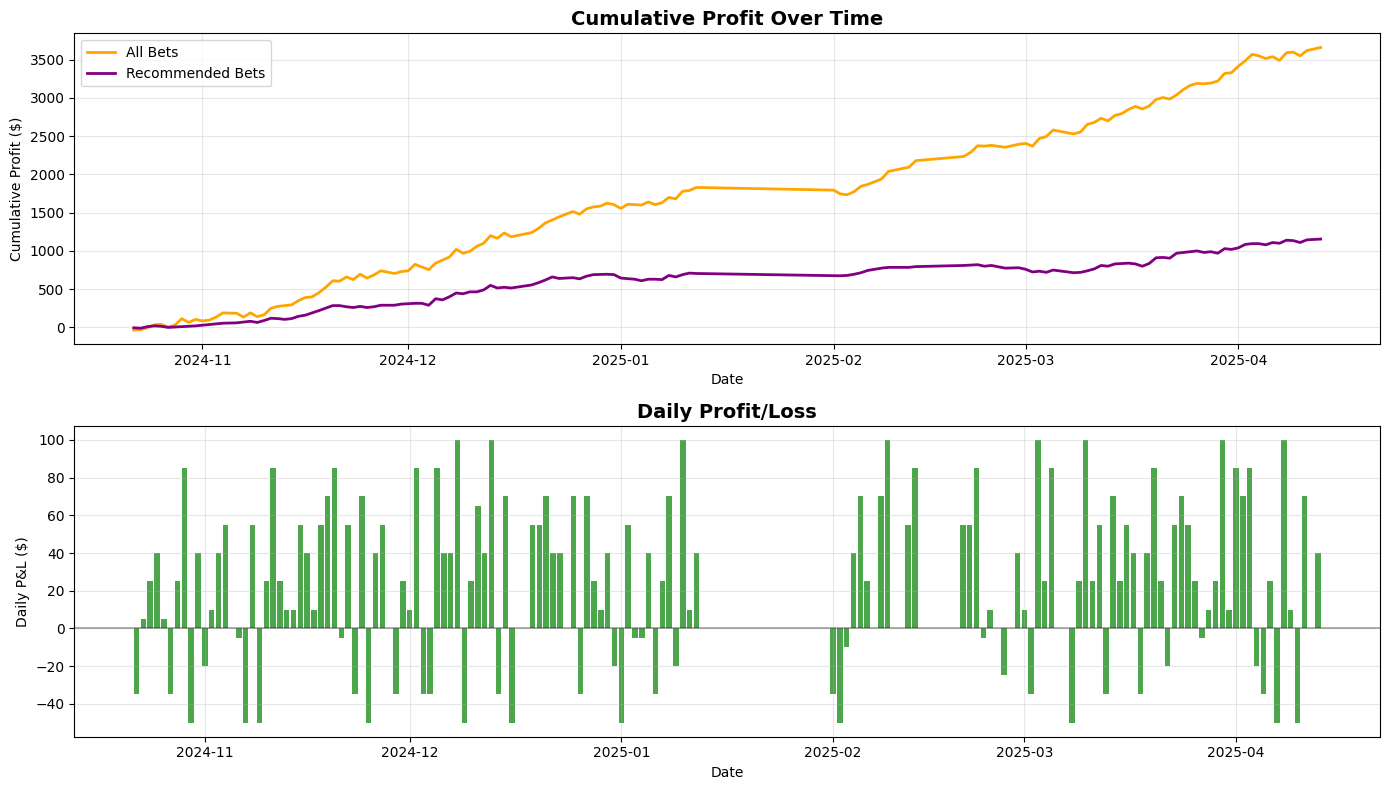

In [7]:
all_metrics = calculatePairMetrics(final_results, stake=5)

# Calculate metrics for recommended bets only
recommended = final_results[final_results['pair_recommendation'] == 1]
rec_metrics = calculatePairMetrics(recommended, stake=5)

# Display comprehensive results
print("=" * 60)
print("           COMPREHENSIVE BETTING ANALYSIS")
print("=" * 60)

if all_metrics:
    print(f"\n ALL BETS ANALYSIS:")
    print(f"   Total Bets: {all_metrics['total_bets']:,}")
    print(f"   Wins: {all_metrics['total_wins']:,}")
    print(f"   Hit Rate: {all_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${all_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${all_metrics['total_staked']:,.2f}")
    print(f"   ROI: {all_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${all_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${all_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {all_metrics['sharpe_ratio']:.3f}")
    
    # Display probability metrics
    if 'probability_metrics' in all_metrics and 'error' not in all_metrics['probability_metrics']:
        prob_metrics = all_metrics['probability_metrics']
        print(f"\n   PROBABILITY METRICS:")
        print(f"   Brier Score: {prob_metrics.get('brier_score', 'N/A'):.4f} (lower is better)")
        print(f"   Log Loss: {prob_metrics.get('log_loss', 'N/A'):.4f} (lower is better)")
        if not np.isnan(prob_metrics.get('auc_roc', np.nan)):
            print(f"   AUC-ROC: {prob_metrics.get('auc_roc', 'N/A'):.4f} (higher is better)")
        else:
            print(f"   AUC-ROC: NaN ({prob_metrics.get('auc_roc_note', 'Only one class present')})")
        print(f"   Samples: {prob_metrics.get('n_samples', 'N/A')}")

if rec_metrics:
    print("\n RECOMMENDED BETS ANALYSIS (Edge > 0.20):")
    print(f"   Total Bets: {rec_metrics['total_bets']:,}")
    print(f"   Wins: {rec_metrics['total_wins']:,}")
    print(f"   Hit Rate: {rec_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${rec_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${rec_metrics['total_staked']:,.2f}")
    print(f"   ROI: {rec_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${rec_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${rec_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {rec_metrics['sharpe_ratio']:.3f}")
    
    # Display probability metrics for recommended bets
    if 'probability_metrics' in rec_metrics and 'error' not in rec_metrics['probability_metrics']:
        prob_metrics = rec_metrics['probability_metrics']
        print(f"\n   PROBABILITY METRICS:")
        print(f"   Brier Score: {prob_metrics.get('brier_score', 'N/A'):.4f} (lower is better)")
        print(f"   Log Loss: {prob_metrics.get('log_loss', 'N/A'):.4f} (lower is better)")
        if not np.isnan(prob_metrics.get('auc_roc', np.nan)):
            print(f"   AUC-ROC: {prob_metrics.get('auc_roc', 'N/A'):.4f} (higher is better)")
        else:
            print(f"   AUC-ROC: NaN ({prob_metrics.get('auc_roc_note', 'Only one class present')})")
        print(f"   Samples: {prob_metrics.get('n_samples', 'N/A')}")

# Plots cumulative profit over time
if all_metrics and not all_metrics['daily_pnl'].empty:
    plt.figure(figsize=(14, 8))
    
    plt.subplot(2, 1, 1)
    plt.plot(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['cumulative_profit'], 
             linewidth=2, label='All Bets', color='orange')
    if rec_metrics and not rec_metrics['daily_pnl'].empty:
        plt.plot(rec_metrics['daily_pnl']['date'], rec_metrics['daily_pnl']['cumulative_profit'], 
                 linewidth=2, label='Recommended Bets', color='purple')
    plt.title('Cumulative Profit Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Profit ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 1, 2)
    plt.bar(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['profit'], 
            alpha=0.7, label='Daily P&L', color='green')
    plt.title('Daily Profit/Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Daily P&L ($)')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()